In [ ]:
from sklearn.metrics import root_mean_squared_error
import numpy as np

def get_rmse_4(model, X, y_true):
    """
    Calculate RMSE for a given model and dataset.

    Parameters:
    -----------
    model : fitted sklearn model or pipeline
    X : features (DataFrame or array)
    y_true : true target values

    Returns:
    --------
    float : RMSE value
    """
    y_pred = model.predict(X)
    rmse = root_mean_squared_error(y_true, y_pred)
    return rmse

# Test the function
print("Function created successfully!")

Function created successfully!


**Now it is time to answer MCQ 2.4.2.1.**

---

## 3. Training All Candidate Models

We evaluate four models that span a spectrum from no-model (baseline) to regularized with automatic hyperparameter selection:

| Model | Type | Regularization | Hyperparameter selection |
|-------|------|----------------|--------------------------|
| **Baseline** | Mean predictor | None | None |
| **Linear Regression** | OLS | None | None (closed-form) |
| **Ridge** | L2 regularized | $\alpha \sum \beta_j^2$ | Automatic via RidgeCV |
| **Lasso** | L1 regularized | $\alpha \sum \|\beta_j\|$ | Automatic via LassoCV |

**Why include the baseline?**

The mean baseline is the floor — the performance any model should easily surpass. If a sophisticated regularized model barely outperforms the baseline, something is wrong: either the features do not contain useful signal, or the data preparation is flawed. The baseline keeps us honest.

**Why use RidgeCV and LassoCV here?**

In Lesson 3, we manually tuned $\alpha$ by testing a grid and reading the U-curve. In a production evaluation, we want the best possible version of each model — not a version that was manually tuned with a coarse grid. RidgeCV and LassoCV use 5-fold cross-validation to select $\alpha$ rigorously, ensuring each regularized model is at its best for the final comparison.

### 3.1 Baseline Model

In [ ]:
# Calculate mean
y_mean_4 = y_train_4.mean()

# Create baseline predictions
y_pred_baseline_train = [y_mean_4] * len(y_train_4)
y_pred_baseline_test = [y_mean_4] * len(y_test_4)

# Calculate RMSE
rmse_base_train = root_mean_squared_error(y_train_4, y_pred_baseline_train)
rmse_base_test = root_mean_squared_error(y_test_4, y_pred_baseline_test)

print(f"Baseline Train RMSE: ${rmse_base_train:,.2f}")
print(f"Baseline Test RMSE: ${rmse_base_test:,.2f}")

Baseline Train RMSE: $59,700.25
Baseline Test RMSE: $57,576.13


### 3.2 Linear Regression Model

The unregularized OLS model serves as a reference point: how well can we do when we use all available features but apply no regularization penalty?

**Code Task 2.4.3.2**

In [ ]:


model_linear_4 = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LinearRegression()
)

# Fit the model on training data
model_linear_4.fit(X_train_4, y_train_4)

# Evaluate using your custom RMSE function
rmse_linear_train = get_rmse_4(model_linear_4, X_train_4, y_train_4)
rmse_linear_test = get_rmse_4(model_linear_4, X_test_4, y_test_4)

print(f"Linear Regression Train RMSE: ${rmse_linear_train:,.2f}")
print(f"Linear Regression Test RMSE: ${rmse_linear_test:,.2f}")

Linear Regression Train RMSE: $34,200.43
Linear Regression Test RMSE: $33,088.37


### 3.3 Ridge Regression (RidgeCV)

Ridge applies the L2 penalty: $\alpha \sum \beta_j^2$. All features are retained but their coefficients are shrunk. `RidgeCV` selects $\alpha$ automatically via 5-fold cross-validation.

**Code Task 2.4.3.3**

In [ ]:
model_ridge_4 = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 4, 100))
)

# Fit the model on training data
model_ridge_4.fit(X_train_4, y_train_4)

# Evaluate using your custom RMSE function
rmse_ridge_train = get_rmse_4(model_ridge_4, X_train_4, y_train_4)
rmse_ridge_test = get_rmse_4(model_ridge_4, X_test_4, y_test_4)

# Extract the tuned alpha value
alpha_ridge_chosen = model_ridge_4.named_steps["ridgecv"].alpha_
print(f"Best Ridge alpha: {alpha_ridge_chosen:.6f}")
print(f"Ridge Train RMSE: ${rmse_ridge_train:,.2f}")
print(f"Ridge Test RMSE: ${rmse_ridge_test:,.2f}")

Best Ridge alpha: 43.287613
Ridge Train RMSE: $34,203.95
Ridge Test RMSE: $33,071.27


### 3.4 Lasso Regression (LassoCV)

Lasso applies the L1 penalty: $\alpha \sum |\beta_j|$. Some coefficients are driven exactly to zero — automatic feature selection. `LassoCV` selects $\alpha$ automatically.

**Code Task 2.4.3.4**

In [ ]:

model_lasso_4 = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 2, 100), max_iter=10000)
)

# Fit the model on training data
model_lasso_4.fit(X_train_4, y_train_4)

# Evaluate using your custom RMSE function
rmse_lasso_train = get_rmse_4(model_lasso_4, X_train_4, y_train_4)
rmse_lasso_test = get_rmse_4(model_lasso_4, X_test_4, y_test_4)

# Extract the tuned alpha value
alpha_lasso_chosen = model_lasso_4.named_steps["lassocv"].alpha_
print(f"Best Lasso alpha: {alpha_lasso_chosen:.6f}")
print(f"Lasso Train RMSE: ${rmse_lasso_train:,.2f}")
print(f"Lasso Test RMSE: ${rmse_lasso_test:,.2f}")

Best Lasso alpha: 32.745492
Lasso Train RMSE: $34,203.20
Lasso Test RMSE: $33,069.18


In [ ]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169844169", h="3298dbabb7", width=700, height=450) https://vimeo.com/1169844169

### 3.5 What to Expect from Each Model

Before examining the comparison table, develop intuitions about what each model should show:

**Baseline:** Both train and test RMSE will be equal (or nearly so) and high. The baseline has no capacity to overfit because it learns only the mean — it produces the same prediction for every apartment regardless of features.

**Linear Regression:** Potentially good performance, but training RMSE will be significantly lower than test RMSE if the model is overfitting. With 50+ features (many from one-hot encoding), there are many opportunities to fit noise in the training data.

**Ridge:** Similar test RMSE to Linear Regression, but a smaller generalization gap. Ridge's L2 penalty should reduce overfitting by shrinking large coefficients — making training performance slightly worse (intentionally) while improving test performance.

**Lasso:** Similar test RMSE to Ridge, with the additional property that some coefficients are exactly zero. The model is simpler and more interpretable than the other two. If the test RMSE is comparable to Ridge and Linear Regression, Lasso is the preferred choice for deployment because its sparsity makes it easier to explain and audit.

> 🚦 **The key decision metric is Test RMSE** — not Training RMSE. A model that achieves lower training RMSE by overfitting is not actually better; it just memorized more training-set noise.


---

## 4. The Unified Comparison Table

A unified comparison table is the standard tool for model selection. It places all candidates side by side on the metrics that matter, making the selection decision explicit and auditable.

**Code Task 2.4.4.1**: Build `df_results_4` — a DataFrame comparing all four models with columns for Model name, Train RMSE, Test RMSE, and the Generalization Gap (Test − Train RMSE).

In [ ]:
# Build Results Table
import pandas as pd

data_4 = {
    "Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE": [
        rmse_base_train,
        rmse_linear_train,
        rmse_ridge_train,
        rmse_lasso_train
    ],
    "Test_RMSE": [
        rmse_base_test,
        rmse_linear_test,
        rmse_ridge_test,
        rmse_lasso_test
    ]
}

df_results_4 = pd.DataFrame(data_4)

# Calculate Generalization Gap
df_results_4["Gap"] = df_results_4["Test_RMSE"] - df_results_4["Train_RMSE"]

# Set Model as index for better display
df_results_4 = df_results_4.set_index("Model")

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(df_results_4.round(2))
print("="*60)


MODEL COMPARISON TABLE
                   Train_RMSE  Test_RMSE      Gap
Model                                            
Baseline             59700.25   57576.13 -2124.12
Linear Regression    34200.43   33088.37 -1112.06
Ridge (CV-tuned)     34203.95   33071.27 -1132.68
Lasso (CV-tuned)     34203.20   33069.18 -1134.01


> **Reading the Comparison Table**
>
> | Column | Meaning | What to look for |
> |--------|---------|-----------------|
> | **Train_RMSE** | Error on data the model learned from | Alone, this is misleading — low Train RMSE just means the model fit its training examples |
> | **Test_RMSE** | Error on data the model never saw | **This is the honest measure of real-world performance** |
> | **Gap** | Test RMSE − Train RMSE | Small gap = good generalization; large gap = overfitting; gap ≈ 0 for baseline (it always predicts the same value) |
>
> **What this table reveals:**
>
> - The **baseline** has near-zero gap because it predicts the same value (training mean) for every apartment — it cannot overfit because it does not learn
> - **Linear Regression** has a small gap if the regularization-free model generalizes; a large gap if it overfits
> - **Ridge and Lasso** should have smaller gaps than Linear Regression if regularization is helping
> - If all three predictive models have similar Test RMSE, the differences are not meaningful — choose based on other criteria (interpretability, simplicity, sparsity)

**Now it is time to answer MCQ 2.4.4.1. and MCQ 2.4.4.2.**

---

## 5. Visualizing Model Performance

### 5.1 Predicted vs. Actual Plot

The predicted-vs-actual scatter plot reveals *where* the model's errors occur. The 45° diagonal represents perfect predictions; distance from this line measures error magnitude.

**Code 2.4.5.1**: Create a predicted vs. actual scatter plot for the Lasso model.

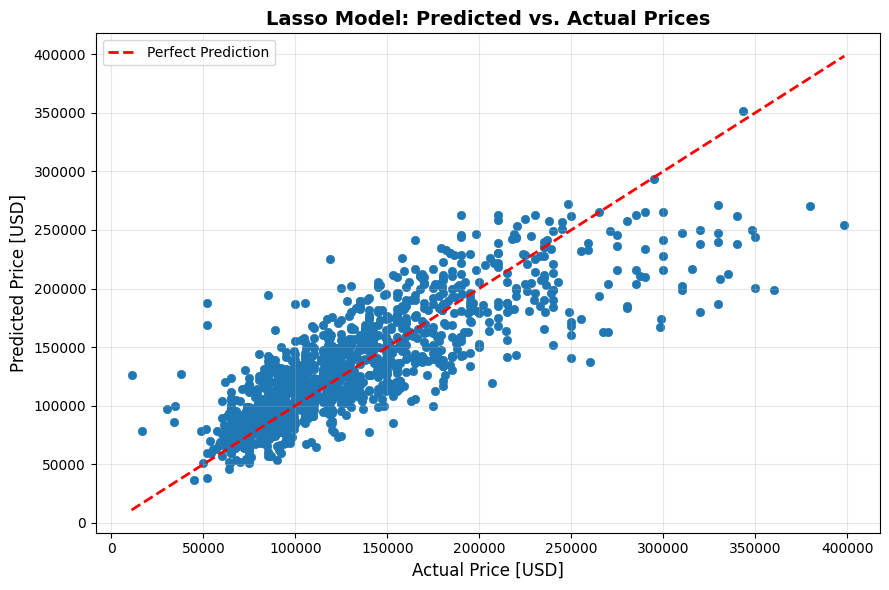

In [ ]:
y_pred_lasso_4 = model_lasso_4.predict(X_test_4)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_test_4, y_pred_lasso_4, linewidth=0.5)

ideal_line = np.linspace(y_test_4.min(), y_test_4.max(), 100)
ax.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2, label="Perfect Prediction")

ax.set_xlabel("Actual Price [USD]", fontsize=12)
ax.set_ylabel("Predicted Price [USD]", fontsize=12)
ax.set_title("Lasso Model: Predicted vs. Actual Prices", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Now it is time to answer MCQ 2.4.5.1.**

### 5.2 Residual Analysis

Residual plots reveal patterns that aggregate metrics hide. A model can have an acceptable average RMSE while still making *systematic* errors — consistently underestimating expensive apartments while overestimating cheap ones, for example. Residuals expose these patterns.

**Code 2.4.5.2**: Create a residual plot (actual − predicted vs. predicted values) for the Lasso model.

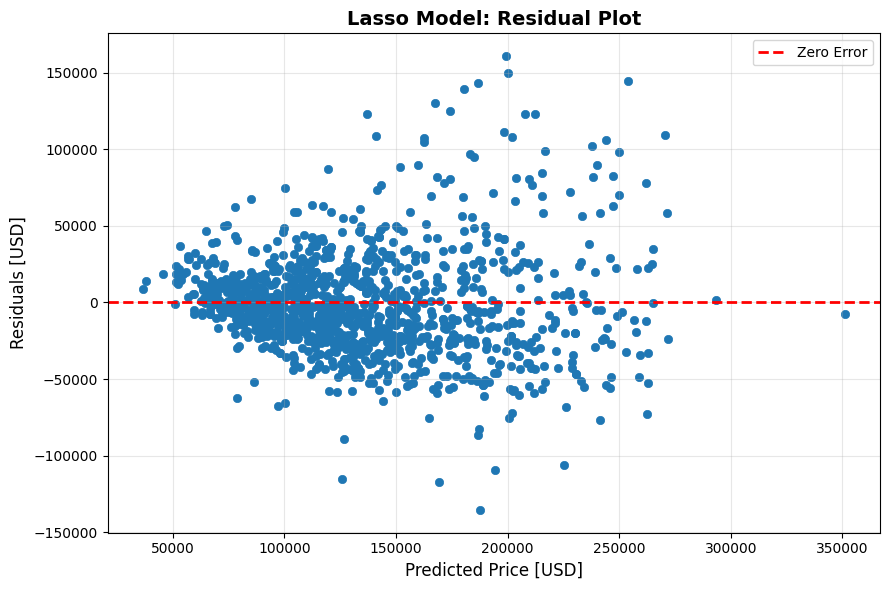

In [ ]:
residuals_4 = y_test_4 - y_pred_lasso_4

fig_res, ax_res = plt.subplots(figsize=(9, 6))
ax_res.scatter(y_pred_lasso_4, residuals_4, linewidth=0.5)
ax_res.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax_res.set_xlabel("Predicted Price [USD]", fontsize=12)
ax_res.set_ylabel("Residuals [USD]", fontsize=12)
ax_res.set_title("Lasso Model: Residual Plot", fontsize=14, fontweight='bold')
ax_res.legend(fontsize=10)
ax_res.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Diagnosing Heteroscedasticity: The Funnel Pattern**
>
> The residual plot likely shows a **funnel shape** — residuals are tightly clustered for low predicted prices and increasingly spread for higher predicted prices. This is called **heteroscedasticity** (non-constant error variance).
>
> **Why it appears in price data:**
> Expensive properties are more unique — they have features (historic architecture, premium materials, iconic addresses) that our model does not capture. A 50m² apartment in Palermo sells for a highly predictable price; a rare 200m² penthouse with a private terrace in Puerto Madero is priced by factors entirely outside our feature set.
>
> **What it means for the model's reliability:**
>
> Heteroscedasticity violates one of OLS's core assumptions. The practical consequences:
> - **Standard errors** on coefficients are biased — confidence intervals are wrong, especially for expensive properties
> - **Prediction intervals** are unreliable — you cannot trust the model to say "the true price is between $X and $Y" for high-end listings
> - The model's average RMSE underrepresents its errors at the expensive end of the market
>
> **What this tells us for deployment:** This model is most reliable for typical mid-range apartments where training data is dense. For luxury properties, the error range is substantially larger than the headline RMSE suggests. Any deployment should communicate this caveat explicitly.
>
> ❓ **Can we fix heteroscedasticity?** Partially. Log-transforming the target variable (`np.log(price)`) can reduce it — errors become multiplicative rather than additive. Non-linear models (Random Forest, XGBoost) can capture the complex relationships that drive luxury pricing. Both approaches are beyond the scope of this project but are natural next steps.

---

## 6. Feature Importance: The Lasso Advantage

In [ ]:
coefs_4 = model_lasso_4.named_steps["lassocv"].coef_
feature_names_4 = model_lasso_4.named_steps["onehotencoder"].get_feature_names_out()

# Create the pandas Series for easy analysis
feat_imp_4 = pd.Series(coefs_4, index=feature_names_4)

print(f"Total features: {len(feat_imp_4)}")
print(f"Non-zero features: {(feat_imp_4 != 0).sum()}")
print("\nTop 5 positive coefficients:")
print(feat_imp_4.nlargest(5))
print("\nTop 5 negative coefficients:")
print(feat_imp_4.nsmallest(5))

Total features: 59
Non-zero features: 58

Top 5 positive coefficients:
surface_covered_in_m2         40346.180348
neighborhood_Puerto Madero     9793.898166
neighborhood_Palermo           9684.053726
lat                            8837.497355
neighborhood_Belgrano          7270.101180
dtype: float64

Top 5 negative coefficients:
neighborhood_Balvanera      -5420.759156
neighborhood_Boca           -4734.035389
neighborhood_Once           -4527.997089
neighborhood_Congreso       -3353.222368
neighborhood_Constitución   -2736.586612
dtype: float64


### 6.2 Lasso's Sparsity: Features Dropped

A key advantage of Lasso over Ridge and Linear Regression is that it identifies which features are not worth including — setting their coefficients exactly to zero. The count of zeroed coefficients is a direct measure of how much Lasso simplified the model relative to what it started with.

**Code Task 2.4.6.2**: Calculate how many features have been set to exactly zero by the Lasso model.

In [ ]:
zero_features_4 = (feat_imp_4 == 0).sum() # (feat_imp_4 == 0).sum()
total_features_4 = len(feat_imp_4)
percent_eliminated_4 = (zero_features_4 / total_features_4) * 100

print(f"Lasso eliminated {zero_features_4} out of {total_features_4} features.")
print(f"Percentage eliminated: {percent_eliminated_4:.1f}%")

Lasso eliminated 1 out of 59 features.
Percentage eliminated: 1.7%


**Now it is time to answer MCQ 2.4.6.1.**

### 6.3 Visualizing the Top Features

The horizontal bar chart ranks features by absolute coefficient value — the most influential features have the longest bars, whether positive (price premium) or negative (price discount).

> 🧠 **Reading the feature importance chart:**
>
> - **Positive coefficients:** Being in this neighborhood (or having larger surface area) is associated with higher predicted prices
> - **Negative coefficients:** Being in this neighborhood is associated with lower predicted prices relative to the baseline
> - **Near-zero or absent features:** Lasso zeroed them out — the model determined they do not add useful predictive signal after accounting for all other features

**Code 2.4.6.3**

In [ ]:
fig_feat, ax_feat = plt.subplots(figsize=(9, 6))
feat_imp_4.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax_feat)
ax_feat.set_title("Top 10 Most Important Features (Lasso)", fontsize=14, fontweight='bold')
ax_feat.set_xlabel("Coefficient Value", fontsize=12)
ax_feat.set_ylabel("Feature", fontsize=12)
ax_feat.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 The Dominant Feature

Among all the features the Lasso model retained, one will have the highest absolute coefficient — the single strongest price signal in the model. Identifying it serves as a sanity check: does the feature the model considers most important make intuitive sense given your knowledge of Buenos Aires real estate?

**Code Task 2.4.6.4**: Identify the feature with the highest absolute coefficient and assign it to `top_feature_4`.

In [ ]:
top_feature_4 = feat_imp_4.idxmax()
top_coefficient_4 = feat_imp_4.max()

print(f"The most influential positive feature is: {top_feature_4}")
print(f"Its coefficient is: ${top_coefficient_4:,.2f}")

### 6.5 What the Dominant Feature Tells Us

The feature with the highest absolute coefficient is the single strongest linear price predictor the model found — after controlling for all other features and after Lasso has already eliminated noise features.

**How to interpret it:**

If `top_feature_4` is a neighborhood indicator (e.g., `neighborhood_PuertoMadero`), it means: "After accounting for apartment size and geographic coordinates, being in Puerto Madero is associated with the largest price premium of any factor the model knows about."

If `top_feature_4` is a numeric feature like `surface_covered_in_m2`, it means the model found that size (not neighborhood) is the single strongest predictor — perhaps because the neighborhood effects, while present, are more diffuse across many indicators.

**The sanity check:** Does this make intuitive sense? Puerto Madero is Buenos Aires's most expensive luxury waterfront district. Palermo Soho is a premium trendy neighborhood. If the dominant feature is one of these prestigious neighborhoods, the model has learned something real about the market. If the dominant feature is something unexpected, it may indicate a data artifact worth investigating.

> ❓ **A question to reflect on:** If you were a real estate agent, would you trust a model whose dominant predictor is an obscure neighborhood with only a handful of training examples? How would you check whether a high coefficient reflects a true price premium or just statistical noise from small sample size?


---

## 7. Final Model Recommendation

A model selection decision is not just a number comparison — it is a structured argument. A professional recommendation states: which model, on what evidence, with what caveats, and for what deployment context.

**The structured recommendation template:**

A rigorous final recommendation answers four questions:
1. **Which model performs best on the primary metric (Test RMSE)?**
2. **Is the difference meaningful** — or are the models statistically equivalent?
3. **Are there secondary criteria** (interpretability, sparsity, robustness) that favor a different choice?
4. **What are the known limitations** that the deployment team must understand?

**Code Task 2.4.7.1**: Fill in the recommendation template below with your observed values and interpretation.

In [ ]:
# Find which model has the lowest test RMSE
best_model = ...  # df_results_4["Test_RMSE"].idxmin()

recommendation = f"""
=================================================================
FINAL MODEL SELECTION REPORT
=================================================================

EXECUTIVE SUMMARY:
Based on comprehensive evaluation, I recommend the {best_model} model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: ${rmse_base_test:,.2f}
- Linear Regression Test RMSE: ${rmse_linear_test:,.2f}
- Ridge (CV-tuned) Test RMSE: ${rmse_ridge_test:,.2f}
- Lasso (CV-tuned) Test RMSE: ${rmse_lasso_test:,.2f}

GENERALIZATION ANALYSIS:
The {best_model} model shows the best balance between low test error
and minimal generalization gap, indicating it will perform
reliably on new, unseen properties.

INTERPRETABILITY:
The Lasso model eliminated {zero_features_4} out of
{total_features_4} features ({percent_eliminated_4:.1f}%),
making it highly interpretable for business stakeholders.

KEY PREDICTORS:
The most influential feature is: {top_feature_4}

RECOMMENDATION:
I recommend deploying the {best_model} model because:
1. [Your reason 1 - consider test RMSE performance]
2. [Your reason 2 - consider generalization gap]
3. [Your reason 3 - consider interpretability or simplicity]

=================================================================
"""

print(recommendation)

> **Important Note on Model Selection**
>
> While the solution above picks the model with the lowest test RMSE, in
> practice all three models (Linear Regression, Ridge, and Lasso)
> perform nearly identically. The differences are minimal and not
> statistically significant. Your choice between them should consider: -
> **Simplicity**: Linear Regression is the simplest -
> **Interpretability**: Lasso provides sparsity (fewer features) -
> **Robustness**: Ridge is more robust to multicollinearity
>
> Additionally, the residual plot reveals heteroscedasticity (larger
> errors for expensive properties), suggesting that linear models may
> have fundamental limitations for this problem. A ~26% error rate
> relative to the mean price is substantial and should prompt
> consideration of more advanced techniques.

**Multiple Choice Question 2.4.7.1**

After comparing all three predictive models, what do you observe about
their test RMSE performance?

1.  Linear Regression is clearly superior to Ridge and Lasso
2.  All three models perform essentially equivalently with negligible
    differences \[x\]
3.  Lasso significantly outperforms both Linear and Ridge
4.  Ridge is consistently the worst performer

*Now it is time to answer MCQ 2.4.7.1.*

**Multiple Choice Question 2.4.7.2**

Why does regularization (Ridge/Lasso) help improve model performance?

1.  It makes the model train faster
2.  It prevents overfitting by penalizing large coefficients \[x\]
3.  It automatically adds more features
4.  It removes the need for train-test splits

*Now it is time to answer MCQ 2.4.7.2.*

------------------------------------------------------------------------

## Summary & Key Takeaways

Congratulations! We have completed Project 2. We didn’t just build a
model; we built a **pipeline** for decision-making—and learned when that
pipeline has limitations.

> **What We Learned**
>
> **1. Comparison is Key**: You can’t know if a model is “good” until
> you compare it to a baseline and other candidates
>
> **2. Statistical Equivalence Matters**: When models perform nearly
> identically, the best choice depends on business priorities
> (simplicity, interpretability, robustness), not raw metrics
>
> **3. Know Your Data Shape**: Regularization is most effective on wide
> datasets (more features than rows). On tall datasets with many
> examples, simple models often match complex ones
>
> **4. Assumption Violations Signal Limitations**: The funnel-shaped
> residual plot (heteroscedasticity) reveals that linear models may not
> be ideal for this problem. Always check model assumptions!
>
> **5. Error Rates in Context**: A 26% error rate beats the baseline but
> is substantial enough to warrant skepticism about real-world
> deployment
>
> **6. Hyperparameter Tuning Matters**: Using RidgeCV and LassoCV
> automatically selects optimal regularization, avoiding manual guessing
>
> **7. Interpretability Matters**: When multiple models tie on
> performance, sparsity and interpretability become decision factors

> **Model Selection Best Practices**
>
> 1.  **Always use a baseline** for comparison
> 2.  **Evaluate on consistent test data** across all models
> 3.  **Use cross-validation for hyperparameter tuning** (RidgeCV,
>     LassoCV) rather than manual selection
> 4.  **Look beyond just test error** - consider generalization gap and
>     practical differences
> 5.  **Check model assumptions** with residual plots to identify
>     violations (heteroscedasticity, etc.)
> 6.  **Visualize predictions** to understand model behavior and
>     limitations
> 7.  **Consider interpretability** for business applications - when
>     models tie, it matters
> 8.  **Understand your data** - regularization helps most with wide
>     data; simple models excel on tall data
> 9.  **Document your decision** with evidence-based reasoning **and
>     caveats**

**Now it is time to answer MCQ 2.4.8.1.**

------------------------------------------------------------------------

## Discussion Questions

1.  **Business Decision**: If you were the CEO of a real estate startup,
    would you choose the Ridge model or the Lasso model? Why?

2.  **Missing Data**: Our model still struggles with very expensive
    homes. What data are we missing?

3.  **Geographic Generalization**: How would this model change if we
    were looking at houses in a different city?

4.  **Feature Engineering**: Looking at the top 10 important features,
    can you think of new features we could engineer?

5.  **Alpha Selection**: How would you systematically find the optimal
    alpha values?

6.  **Deployment Considerations**: If you were to deploy this model in
    production, what monitoring would you put in place?

------------------------------------------------------------------------

## Reflection Exercise

1.  Which model would you deploy and why?
2.  What are the most predictive features and do they make intuitive
    sense?
3.  Does regularization help in this case? How do you know?
4.  What would you do differently if you had more time or data?

------------------------------------------------------------------------

## Next Steps

Congratulations on finishing Project 2! You’ve learned the complete
workflow for supervised machine learning:

1.  **Data Cleaning** (Lesson 1)
2.  **Visualization** (Lesson 2)
3.  **Regularization** (Lesson 3)
4.  **Model Selection** (Lesson 4)

Great job! You are now ready to take these predictive skills into even
more complex datasets and business problems!